In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import netCDF4 as nc
from scipy.interpolate import RegularGridInterpolator

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import day_plot, compute_AR_from_Q


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'

dataset = nc.Dataset(fname)

lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))

def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2

dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])

x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')


In [3]:
df_tracked = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tracked_50m_vert_checked.pkl')

df_tracked['q11'] = [Q[0,0] for Q in df_tracked.Q]
df_tracked['q12'] = [Q[1,0] for Q in df_tracked.Q]
df_tracked['q22'] = [Q[1,1] for Q in df_tracked.Q]

# smooth Q components within each eddy track
smooth_cols = ['q11', 'q12', 'q22']

df_tracked[smooth_cols] = (
    df_tracked
    .sort_values(['Eddy', 'Day'])
    .groupby('Eddy')[smooth_cols]
    .transform(
        lambda x: x.rolling(
            window=3,
            center=True,
            min_periods=1
        ).mean()
    )
)
    
df_tracked['AR'] = compute_AR_from_Q(np.stack(df_tracked['Q'].values))

df_tracked = df_tracked[['Eddy', 'Day', 'Cyc', 'xc', 'yc', 'w', 'Omega0', 'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R']].copy().sort_values(by=['Eddy', 'Day'])
df_tracked = df_tracked.groupby('Eddy').filter(lambda g: g['Day'].max() - g['Day'].min() >= 21) # Keep only mesoscale - older than 3 weeks

df_tracked


,Eddy,Day,Cyc,xc,yc,w,Omega0,Omega,q11,q12,q22,Rc,psi0,AR,R
2,2,1462,CE,928.181752,1356.070550,-0.000011,-0.000004,-0.000007,1.078039,-0.388225,1.189040,118.032741,47.992205,1.969122,74.597458
82,2,1464,CE,912.061191,1348.117301,-0.000011,-0.000006,-0.000007,1.186788,-0.367353,1.055228,141.148836,74.035424,1.269457,78.300764
117,2,1465,CE,911.162024,1364.461638,-0.000016,-0.000007,-0.000009,1.274357,-0.293598,0.871468,111.650721,56.591801,1.544380,69.625773
146,2,1466,CE,908.463829,1366.554462,-0.000014,-0.000006,-0.000009,1.302035,-0.457566,0.945071,115.925719,57.471319,1.538338,72.613632
178,2,1467,CE,904.237002,1358.094875,-0.000015,-0.000006,-0.000008,1.296619,-0.547406,1.007739,114.735400,53.782119,1.807915,68.352522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367068,42739,10646,CE,515.983450,302.961328,-0.000026,-0.000013,-0.000005,1.040904,-0.100462,0.978558,296.143990,228.122048,1.099072,55.409919
367097,42739,10647,CE,512.684226,297.695084,-0.000027,-0.000014,-0.000008,1.030802,-0.022352,0.972594,78.707595,25.393893,1.031663,44.896186
367126,42739,10648,CE,514.199660,296.590511,-0.000026,-0.000013,-0.000010,1.056231,-0.010838,0.949624,61.298208,19.369553,1.017029,38.796956
367157,42739,10649,CE,510.019363,305.068558,-0.000025,-0.000012,-0.000009,1.069327,-0.017910,0.937880,64.546558,19.604126,1.136121,40.028670


QC

In [4]:
# Check AR
# if poor only keep Eddy, Day, Cyc, xc, yc, R
# replace the rest NaN

df_tracked_QC = df_tracked.copy()

AR_mask = df_tracked_QC['AR'] > 5
cols_to_nan = [
    'w', 'Omega0', 'Omega',
    'q11', 'q12', 'q22',
    'Rc', 'psi0', 'AR'
]
df_tracked_QC.loc[AR_mask, cols_to_nan] = np.nan

# Check Omega, Rc, psi0 i.e. poor outer-core fits
poor_outer_fits = (
    (df_tracked_QC['Rc'] > 300)
    | (df_tracked_QC['Rc'] > 1.75*df_tracked_QC['R'])
    | (df_tracked_QC['Omega'].abs() > 5e-5)
    | (df_tracked_QC['psi0'].abs() > 300) # maybe remove
)
# replace Omega with Omega0
df_tracked_QC.loc[poor_outer_fits, 'Omega'] = (
    df_tracked_QC.loc[poor_outer_fits, 'Omega0']
)
# remove poor outer-core parameters
df_tracked_QC.loc[poor_outer_fits, ['Rc', 'psi0']] = np.nan

df_tracked_QC = df_tracked_QC.drop(columns='Omega0')
df_tracked_QC


,Eddy,Day,Cyc,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R
2,2,1462,CE,928.181752,1356.070550,-0.000011,-0.000007,1.078039,-0.388225,1.189040,118.032741,47.992205,1.969122,74.597458
82,2,1464,CE,912.061191,1348.117301,-0.000011,-0.000006,1.186788,-0.367353,1.055228,NaN,NaN,1.269457,78.300764
117,2,1465,CE,911.162024,1364.461638,-0.000016,-0.000009,1.274357,-0.293598,0.871468,111.650721,56.591801,1.544380,69.625773
146,2,1466,CE,908.463829,1366.554462,-0.000014,-0.000009,1.302035,-0.457566,0.945071,115.925719,57.471319,1.538338,72.613632
178,2,1467,CE,904.237002,1358.094875,-0.000015,-0.000008,1.296619,-0.547406,1.007739,114.735400,53.782119,1.807915,68.352522
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367068,42739,10646,CE,515.983450,302.961328,-0.000026,-0.000013,1.040904,-0.100462,0.978558,NaN,NaN,1.099072,55.409919
367097,42739,10647,CE,512.684226,297.695084,-0.000027,-0.000014,1.030802,-0.022352,0.972594,NaN,NaN,1.031663,44.896186
367126,42739,10648,CE,514.199660,296.590511,-0.000026,-0.000010,1.056231,-0.010838,0.949624,61.298208,19.369553,1.017029,38.796956
367157,42739,10649,CE,510.019363,305.068558,-0.000025,-0.000009,1.069327,-0.017910,0.937880,64.546558,19.604126,1.136121,40.028670


,Eddy,Day,Cyc,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R
2,2,1462,CE,928.181752,1356.070550,-0.000011,-0.000007,1.078039,-0.388225,1.189040,118.032741,47.992205,1.969122,74.597458
82,2,1464,CE,912.061191,1348.117301,-0.000011,-0.000006,1.186788,-0.367353,1.055228,NaN,NaN,1.269457,78.300764
117,2,1465,CE,911.162024,1364.461638,-0.000016,-0.000009,1.274357,-0.293598,0.871468,111.650721,56.591801,1.544380,69.625773
146,2,1466,CE,908.463829,1366.554462,-0.000014,-0.000009,1.302035,-0.457566,0.945071,115.925719,57.471319,1.538338,72.613632
178,2,1467,CE,904.237002,1358.094875,-0.000015,-0.000008,1.296619,-0.547406,1.007739,114.735400,53.782119,1.807915,68.352522


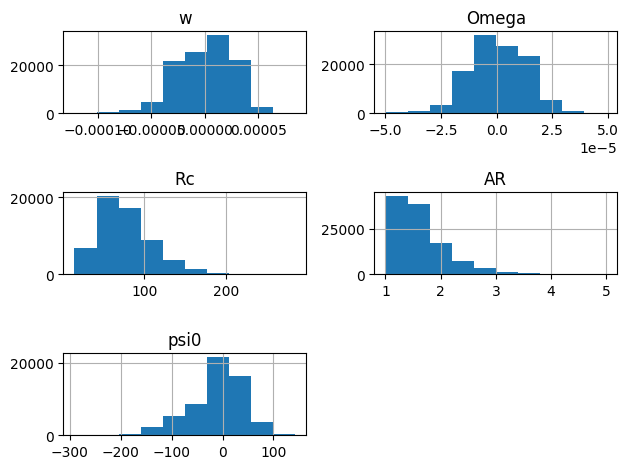

In [5]:
df = df_tracked_QC.copy()
df.hist(['w', 'Omega', 'Rc', 'AR', 'psi0'])
plt.tight_layout()
df.head()


In [6]:
def fill_missing_eddy_days(df, max_outer_gap=14):

    df = df.copy()
    out = []

    interp_cols = [
        'xc', 'yc', 'w', 'Omega',
        'q11', 'q12', 'q22', 'R'
    ]

    outer_cols = ['Rc', 'psi0']

    outer_gap_summary = {col: 0 for col in outer_cols}
    outer_gap_all = {col: [] for col in outer_cols}

    for eddy, g in df.groupby('Eddy'):

        g = g.sort_values('Day').copy()

        full_days = pd.DataFrame({
            'Eddy': eddy,
            'Day': np.arange(g['Day'].min(), g['Day'].max() + 1)
        })

        merged = full_days.merge(g, on=['Eddy', 'Day'], how='left')

        # interpolate standard variables
        existing_interp_cols = [c for c in interp_cols if c in merged.columns]

        merged[existing_interp_cols] = (
            merged[existing_interp_cols]
            .interpolate(method='linear', limit_direction='both')
        )

        # fill Cyc
        if 'Cyc' in merged.columns:
            merged['Cyc'] = merged['Cyc'].ffill().bfill()

        # Rc / psi0 limited interpolation
        for col in outer_cols:

            if col not in merged.columns:
                continue

            y_interp = merged[col].interpolate(
                method='linear',
                limit_direction='both'
            )

            is_nan = merged[col].isna().values
            start = None

            for i, bad in enumerate(is_nan):

                if bad and start is None:
                    start = i

                elif not bad and start is not None:

                    gap = i - start

                    outer_gap_summary[col] = max(
                        outer_gap_summary[col],
                        gap
                    )

                    outer_gap_all[col].append(gap)

                    if gap <= max_outer_gap:
                        merged.loc[
                            merged.index[start:i],
                            col
                        ] = y_interp.iloc[start:i]

                    start = None

            if start is not None:

                gap = len(merged) - start

                outer_gap_summary[col] = max(
                    outer_gap_summary[col],
                    gap
                )

                outer_gap_all[col].append(gap)

                if gap <= max_outer_gap:
                    merged.loc[
                        merged.index[start:],
                        col
                    ] = y_interp.iloc[start:]

        out.append(merged)

    print('\nGap statistics:')
    for col in outer_cols:

        gaps = np.array(outer_gap_all[col])

        if len(gaps):

            print(f'\n{col}')
            print(f'  mean gap   : {gaps.mean():.2f} days')
            print(f'  median gap : {np.median(gaps):.2f} days')
            print(f'  max gap    : {gaps.max()} days')

            plt.figure(figsize=(6,4))
            plt.hist(gaps, bins=np.arange(1, gaps.max()+2)-0.5)
            plt.xlabel('Gap length (days)')
            plt.ylabel('Count')
            plt.title(col)
            plt.show()

    return (
        pd.concat(out, ignore_index=True)
        .sort_values(['Eddy', 'Day'])
        .reset_index(drop=True)
    )
    


Gap statistics:

Rc
  mean gap   : 4.19 days
  median gap : 2.00 days
  max gap    : 62 days


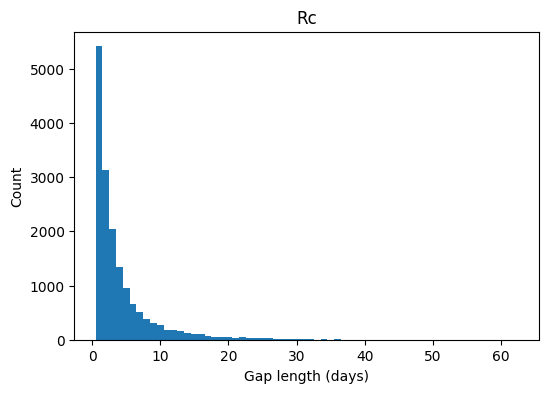


psi0
  mean gap   : 4.19 days
  median gap : 2.00 days
  max gap    : 62 days


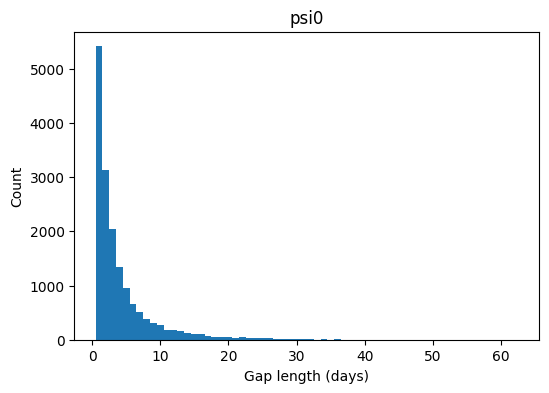

,Eddy,Day,Cyc,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R
0,2,1462,CE,928.181752,1356.070550,-0.000011,-0.000007,1.078039,-0.388225,1.189040,118.032741,47.992205,1.969122,74.597458
1,2,1463,CE,920.121471,1352.093925,-0.000011,-0.000006,1.132413,-0.377789,1.122134,115.905401,50.858737,NaN,76.449111
2,2,1464,CE,912.061191,1348.117301,-0.000011,-0.000006,1.186788,-0.367353,1.055228,113.778061,53.725269,1.269457,78.300764
3,2,1465,CE,911.162024,1364.461638,-0.000016,-0.000009,1.274357,-0.293598,0.871468,111.650721,56.591801,1.544380,69.625773
4,2,1466,CE,908.463829,1366.554462,-0.000014,-0.000009,1.302035,-0.457566,0.945071,115.925719,57.471319,1.538338,72.613632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127513,42739,10646,CE,515.983450,302.961328,-0.000026,-0.000013,1.040904,-0.100462,0.978558,61.312206,19.408106,1.099072,55.409919
127514,42739,10647,CE,512.684226,297.695084,-0.000027,-0.000014,1.030802,-0.022352,0.972594,61.305207,19.388829,1.031663,44.896186
127515,42739,10648,CE,514.199660,296.590511,-0.000026,-0.000010,1.056231,-0.010838,0.949624,61.298208,19.369553,1.017029,38.796956
127516,42739,10649,CE,510.019363,305.068558,-0.000025,-0.000009,1.069327,-0.017910,0.937880,64.546558,19.604126,1.136121,40.028670


In [7]:
df_tracked_filled = fill_missing_eddy_days(df_tracked_QC, max_outer_gap=np.inf)
df_tracked_filled


,Eddy,Day,Cyc,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R
0,2,1462,CE,928.181752,1356.070550,-0.000011,-0.000007,1.078039,-0.388225,1.189040,118.032741,47.992205,1.969122,74.597458
1,2,1463,CE,920.121471,1352.093925,-0.000011,-0.000006,1.132413,-0.377789,1.122134,115.905401,50.858737,NaN,76.449111
2,2,1464,CE,912.061191,1348.117301,-0.000011,-0.000006,1.186788,-0.367353,1.055228,113.778061,53.725269,1.269457,78.300764
3,2,1465,CE,911.162024,1364.461638,-0.000016,-0.000009,1.274357,-0.293598,0.871468,111.650721,56.591801,1.544380,69.625773
4,2,1466,CE,908.463829,1366.554462,-0.000014,-0.000009,1.302035,-0.457566,0.945071,115.925719,57.471319,1.538338,72.613632


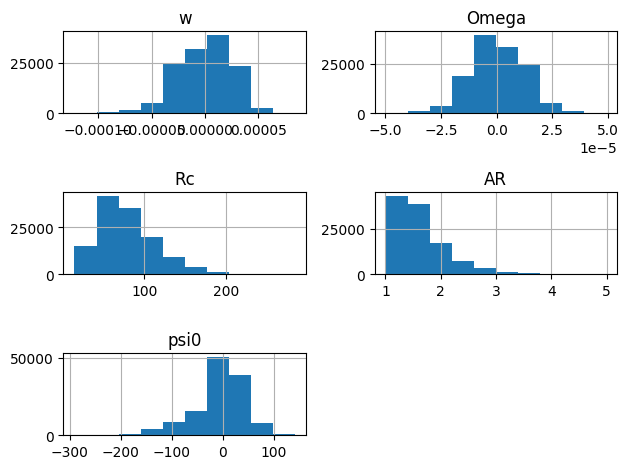

In [8]:
df = df_tracked_filled.copy()
df.hist(['w', 'Omega', 'Rc', 'AR', 'psi0'])
plt.tight_layout()
df.head()


In [9]:
df_eddies = df_tracked_filled.copy()
df_eddies['Eddy'] = df_eddies['Eddy'].rank(method='dense').astype(int) # Relabel the Eddy's 1,2,3..
df_eddies = df_eddies.reset_index(drop=True)
df_eddies


,Eddy,Day,Cyc,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R
0,1,1462,CE,928.181752,1356.070550,-0.000011,-0.000007,1.078039,-0.388225,1.189040,118.032741,47.992205,1.969122,74.597458
1,1,1463,CE,920.121471,1352.093925,-0.000011,-0.000006,1.132413,-0.377789,1.122134,115.905401,50.858737,NaN,76.449111
2,1,1464,CE,912.061191,1348.117301,-0.000011,-0.000006,1.186788,-0.367353,1.055228,113.778061,53.725269,1.269457,78.300764
3,1,1465,CE,911.162024,1364.461638,-0.000016,-0.000009,1.274357,-0.293598,0.871468,111.650721,56.591801,1.544380,69.625773
4,1,1466,CE,908.463829,1366.554462,-0.000014,-0.000009,1.302035,-0.457566,0.945071,115.925719,57.471319,1.538338,72.613632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127513,3013,10646,CE,515.983450,302.961328,-0.000026,-0.000013,1.040904,-0.100462,0.978558,61.312206,19.408106,1.099072,55.409919
127514,3013,10647,CE,512.684226,297.695084,-0.000027,-0.000014,1.030802,-0.022352,0.972594,61.305207,19.388829,1.031663,44.896186
127515,3013,10648,CE,514.199660,296.590511,-0.000026,-0.000010,1.056231,-0.010838,0.949624,61.298208,19.369553,1.017029,38.796956
127516,3013,10649,CE,510.019363,305.068558,-0.000025,-0.000009,1.069327,-0.017910,0.937880,64.546558,19.604126,1.136121,40.028670


In [10]:
# Find Lon and Lat values
xg, yg = x_grid, y_grid
lon_interp = RegularGridInterpolator((yg, xg), lon_rho.T, bounds_error=False, fill_value=np.nan)
lat_interp = RegularGridInterpolator((yg, xg), lat_rho.T, bounds_error=False, fill_value=np.nan)
points = np.column_stack((df_eddies['yc'].to_numpy(), df_eddies['xc'].to_numpy()))
df_eddies['lon'] = lon_interp(points)
df_eddies['lat'] = lat_interp(points)
# Re order columns
cols = df_eddies.columns.tolist()
i = cols.index('Cyc') + 1
base = [c for c in cols if c not in ('lon','lat')]
new_order = base[:i] + ['lon','lat'] + base[i:]
df_eddies = df_eddies[new_order].reset_index(drop=True)
df_eddies


,Eddy,Day,Cyc,lon,lat,xc,yc,w,Omega,q11,q12,q22,Rc,psi0,AR,R
0,1,1462,CE,161.072036,-29.736582,928.181752,1356.070550,-0.000011,-0.000007,1.078039,-0.388225,1.189040,118.032741,47.992205,1.969122,74.597458
1,1,1463,CE,160.982386,-29.745743,920.121471,1352.093925,-0.000011,-0.000006,1.132413,-0.377789,1.122134,115.905401,50.858737,NaN,76.449111
2,1,1464,CE,160.892701,-29.754904,912.061191,1348.117301,-0.000011,-0.000006,1.186788,-0.367353,1.055228,113.778061,53.725269,1.269457,78.300764
3,1,1465,CE,160.929437,-29.612368,911.162024,1364.461638,-0.000016,-0.000009,1.274357,-0.293598,0.871468,111.650721,56.591801,1.544380,69.625773
4,1,1466,CE,160.908986,-29.586156,908.463829,1366.554462,-0.000014,-0.000009,1.302035,-0.457566,0.945071,115.925719,57.471319,1.538338,72.613632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
127513,3013,10646,CE,153.739453,-37.488262,515.983450,302.961328,-0.000026,-0.000013,1.040904,-0.100462,0.978558,61.312206,19.408106,1.099072,55.409919
127514,3013,10647,CE,153.687115,-37.523299,512.684226,297.695084,-0.000027,-0.000014,1.030802,-0.022352,0.972594,61.305207,19.388829,1.031663,44.896186
127515,3013,10648,CE,153.699708,-37.537452,514.199660,296.590511,-0.000026,-0.000010,1.056231,-0.010838,0.949624,61.298208,19.369553,1.017029,38.796956
127516,3013,10649,CE,153.682657,-37.451789,510.019363,305.068558,-0.000025,-0.000009,1.069327,-0.017910,0.937880,64.546558,19.604126,1.136121,40.028670


In [11]:
# Drop eddies where any key field is entirely NaN
check_cols = ['w', 'Omega', 'q11', 'q12', 'q22', 'Rc', 'psi0', 'AR', 'R']

valid_eddies = (
    df_eddies
    .groupby('Eddy')[check_cols]
    .apply(lambda g: ~g.isna().all().any())
)

df_eddies = (
    df_eddies[df_eddies['Eddy'].isin(valid_eddies[valid_eddies].index)]
    .copy()
    .reset_index(drop=True)
)

# Radius filter
df_eddies = (
    df_eddies
    .groupby('Eddy')
    .filter(lambda g: g['R'].mean() > 15)
    .reset_index(drop=True)
)

# Relabel eddies 1, 2, 3, ...
df_eddies['Eddy'] = df_eddies['Eddy'].rank(method='dense').astype(int) # Relabel the Eddy's 1,2,3..

df_eddies['Age'] = df_eddies.groupby('Eddy')['Eddy'].transform('count')

df_eddies['Date'] = (
    pd.Timestamp('1990-01-01')
    + pd.to_timedelta(df_eddies.Day, unit='D')
)

df_eddies['fname'] = [
    f"/srv/scratch/z3533156/26year_BRAN2020/outer_avg_{1461 + ((day - 1462) // 30) * 30:05}.nc"
    for day in df_eddies['Day']
]

ix = np.abs(df_eddies['xc'].values[:, None] - x_grid).argmin(axis=1)
iy = np.abs(df_eddies['yc'].values[:, None] - y_grid).argmin(axis=1)

for col in ['ic', 'jc']:
    if col in df_eddies.columns:
        df_eddies = df_eddies.drop(columns=col)

idx = df_eddies.columns.get_loc('lat') + 1
df_eddies.insert(idx, 'ic', ix)
df_eddies.insert(idx + 1, 'jc', iy)

# Recalcualte AR
Q = np.array([
    [[q11, q12],
     [q12, q22]]
    for q11, q12, q22 in zip(
        df_eddies.q11,
        df_eddies.q12,
        df_eddies.q22
    )
])
df_eddies['AR'] = compute_AR_from_Q(Q)

# recalcualte vorticity w
df_eddies['w'] = df_eddies.Omega * (df_eddies.q11 + df_eddies.q22)

df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.078039,-0.388225,1.189040,118.032741,47.992205,1.434563,74.597458,38,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,1.132413,-0.377789,1.122134,115.905401,50.858737,1.417135,76.449111,38,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.186788,-0.367353,1.055228,113.778061,53.725269,1.413542,78.300764,38,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,1.274357,-0.293598,0.871468,111.650721,56.591801,1.411879,69.625773,38,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,1.302035,-0.457566,0.945071,115.925719,57.471319,1.597888,72.613632,38,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125468,2937,10646,CE,153.739453,-37.488262,181,61,515.983450,302.961328,-0.000026,...,1.040904,-0.100462,0.978558,61.312206,19.408106,1.110214,55.409919,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
125469,2937,10647,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,1.030802,-0.022352,0.972594,61.305207,19.388829,1.037331,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
125470,2937,10648,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000021,...,1.056231,-0.010838,0.949624,61.298208,19.369553,1.055789,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
125471,2937,10649,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000019,...,1.069327,-0.017910,0.937880,64.546558,19.604126,1.070344,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


<Axes: >

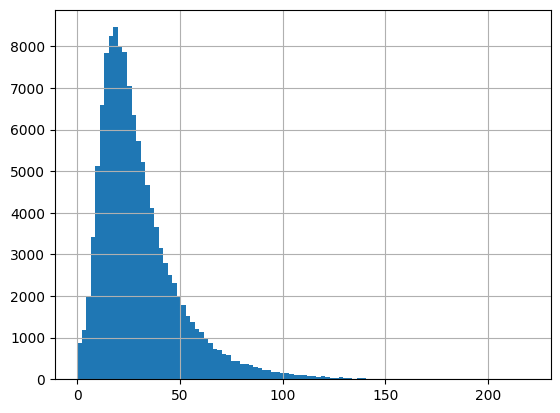

In [12]:
(df_eddies.Rc - df_eddies.R).abs().hist(bins=100)


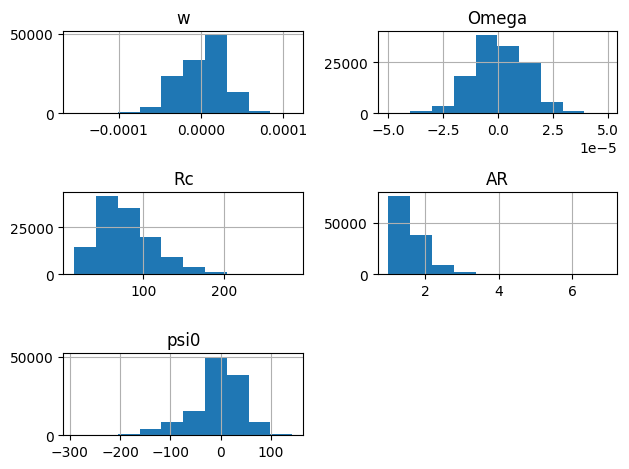

In [13]:
df = df_eddies.copy()
df.hist(['w', 'Omega', 'Rc', 'AR', 'psi0'])
plt.tight_layout()


In [14]:
df_eddies.to_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
/home/z5297792/myenv310/lib/python3.10/site-packages/matplotlib/colors.py:778: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


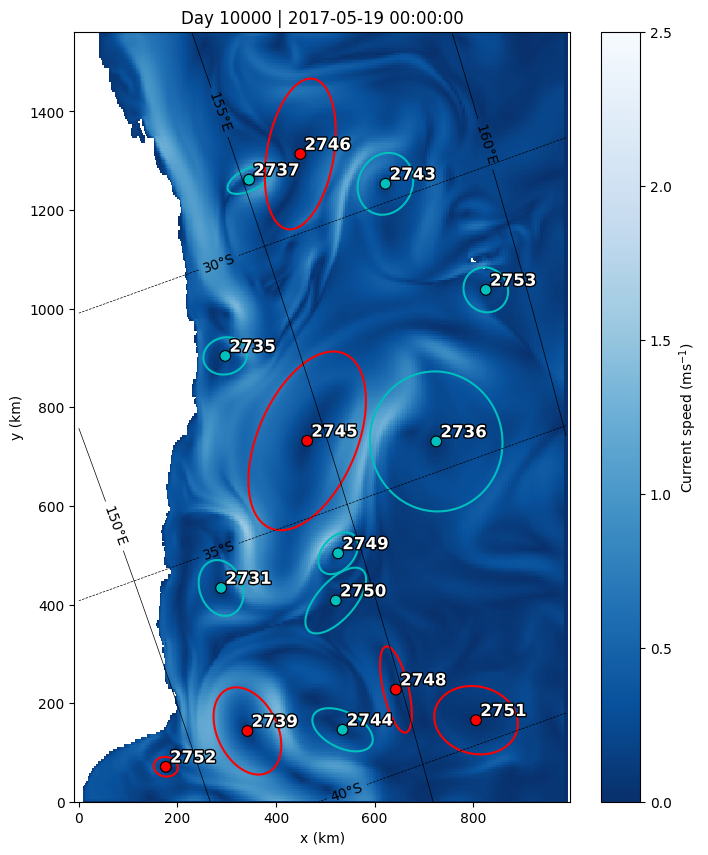

In [19]:
day_plot(10000, df_eddies, out_core_flag=False)


In [20]:
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,1.078039,-0.388225,1.189040,118.032741,47.992205,1.434563,74.597458,38,1994-01-02,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,1.132413,-0.377789,1.122134,115.905401,50.858737,1.417135,76.449111,38,1994-01-03,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,1.186788,-0.367353,1.055228,113.778061,53.725269,1.413542,78.300764,38,1994-01-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,1.274357,-0.293598,0.871468,111.650721,56.591801,1.411879,69.625773,38,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,1.302035,-0.457566,0.945071,115.925719,57.471319,1.597888,72.613632,38,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125468,2937,10646,CE,153.739453,-37.488262,181,61,515.983450,302.961328,-0.000026,...,1.040904,-0.100462,0.978558,61.312206,19.408106,1.110214,55.409919,28,2019-02-24,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
125469,2937,10647,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,1.030802,-0.022352,0.972594,61.305207,19.388829,1.037331,44.896186,28,2019-02-25,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
125470,2937,10648,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000021,...,1.056231,-0.010838,0.949624,61.298208,19.369553,1.055789,38.796956,28,2019-02-26,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
125471,2937,10649,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000019,...,1.069327,-0.017910,0.937880,64.546558,19.604126,1.070344,40.028670,28,2019-02-27,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
